# 1 · Data overview

**Data.** The *All_Beauty* category of Amazon Reviews '23 (Hou et al., 2024), the category studied by
Kung, Orlando & Kirimlioglu (2024), *Were You Helpful – Predicting Helpful Votes from Amazon Reviews*.

This notebook checks that our copy matches the paper's, documents the cleaning, and describes the
variables the later notebooks use.

In [1]:
import sys

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import BLUE, INK_2, fmt_pct, load, savefig, set_style
from config import RAW_SUMMARY

set_style()
df = load()
print(f"{len(df):,} reviews | {df.user_id.nunique():,} reviewers | {df.parent_asin.nunique():,} products")
print(f"{df.time.min():%b %Y} to {df.time.max():%b %Y}")

694,252 reviews | 631,986 reviewers | 112,565 products
Nov 2000 to Sep 2023


## Replication check against Kung et al. (2024), Table 1

The raw file matches the paper's review counts per star rating exactly. The paper's helpful-vote
means are also reproduced. We then drop exact duplicate reviews, which the paper noted as a possible
problem but did not remove.

In [2]:
paper = pd.DataFrame({"rating": [1.0, 2.0, 3.0, 4.0, 5.0],
                      "paper_reviews": [102080, 43034, 56307, 79381, 420726],
                      "paper_mean_helpful": [0.964, 0.748, 0.732, 0.931, 0.956]})
raw = pd.read_csv(RAW_SUMMARY).rename(columns={"reviews": "raw_reviews", "mean_helpful": "raw_mean_helpful"})
clean = (df.groupby("rating").helpful_vote.agg(clean_reviews="size", clean_mean_helpful="mean")
           .reset_index())
replication = paper.merge(raw, on="rating").merge(clean, on="rating")
replication.loc["total"] = replication.sum(numeric_only=True).where(
    replication.columns.str.endswith("reviews"))
replication.round(3)

,rating,paper_reviews,paper_mean_helpful,raw_reviews,raw_mean_helpful,clean_reviews,clean_mean_helpful
0,1.0,102080.0,0.964,102080.0,0.964,100888.0,0.963
1,2.0,43034.0,0.748,43034.0,0.748,42601.0,0.749
2,3.0,56307.0,0.732,56307.0,0.732,55720.0,0.731
3,4.0,79381.0,0.931,79381.0,0.931,78608.0,0.932
4,5.0,420726.0,0.956,420726.0,0.956,416435.0,0.957
total,NaN,701528.0,NaN,701528.0,NaN,694252.0,NaN


## Cleaning

* **Exact duplicates** have the same reviewer, product, timestamp, rating, title and text. We keep
  the first copy.
* **Auto-generated titles.** Amazon used to fill empty titles with the star rating ("Five Stars").
  These titles put the rating into the text, which would make the text look more consistent with
  the rating than the reviewer wrote it. We blank them. The chart shows they are concentrated in
  the mid-2010s.
* HTML tags such as `<br />` and HTML entities are stripped. The sentiment models read the title and
  body joined together.

exact duplicates removed:       7,276
auto-generated titles blanked:  74,564 (10.7% of reviews)
reviews with no text at all:    77


,reviews,auto_title
year,,
2000,1,0.0
2001,11,0.0
2002,24,0.0
2003,56,0.0
2004,130,0.0
2005,265,0.0
2006,416,0.0
2007,1150,0.1
2008,1251,0.0


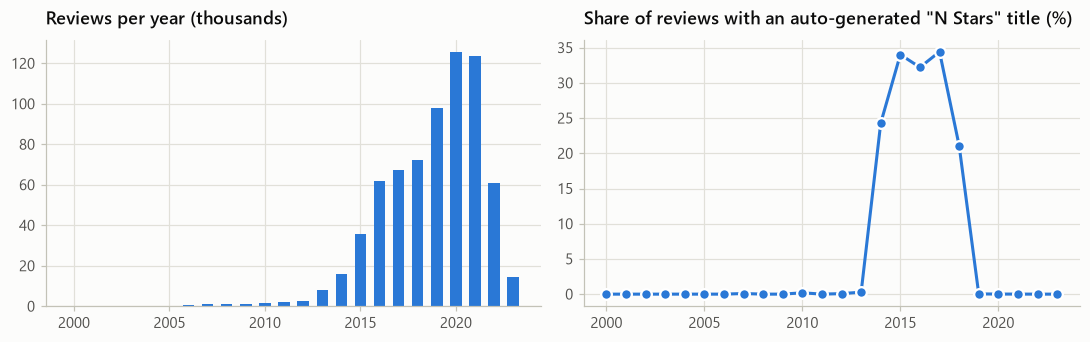

In [3]:
n_raw = int(replication.loc["total", "raw_reviews"])
print(f"exact duplicates removed:       {n_raw - len(df):,}")
print(f"auto-generated titles blanked:  {df.auto_title.sum():,} ({fmt_pct(df.auto_title.mean())} of reviews)")
print(f"reviews with no text at all:    {(df.word_count == 0).sum():,}")

by_year = df.groupby("year").agg(reviews=("review_id", "size"), auto_title=("auto_title", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(by_year.index, by_year.reviews / 1000, width=0.6, color=BLUE)
axes[0].set_title("Reviews per year (thousands)")
axes[1].plot(by_year.index, 100 * by_year.auto_title, color=BLUE, marker="o",
             markeredgecolor="white", markeredgewidth=1.5)
axes[1].set_title('Share of reviews with an auto-generated "N Stars" title (%)')
for ax in axes:
    ax.set_xlabel("")
fig.tight_layout()
savefig(fig, "01_volume_and_auto_titles")
by_year.assign(auto_title=(100 * by_year.auto_title).round(1))

## Star ratings are J-shaped

Most reviews are 5-star, with a secondary peak at 1 star. This matters for what follows. Among
high-star reviews, a small *rate* of negative text still adds up to many reviews. Among low-star
reviews, a higher rate applies to a smaller base.

,reviews,share
rating,,
1.0,100888,0.145
2.0,42601,0.061
3.0,55720,0.080
4.0,78608,0.113
5.0,416435,0.600


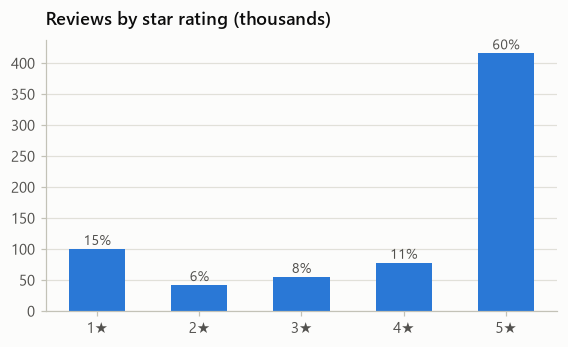

In [4]:
counts = df.rating.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(counts.index, counts / 1000, width=0.55, color=BLUE)
for x, v in counts.items():
    ax.text(x, v / 1000 + 6, f"{v / len(df):.0%}", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(counts.index, [f"{int(r)}★" for r in counts.index])
ax.set_title("Reviews by star rating (thousands)")
ax.grid(axis="x", visible=False)
savefig(fig, "01_rating_distribution")
counts.to_frame("reviews").assign(share=(counts / len(df)).round(3))

## Review length, helpful votes and other review attributes

,value
median words,23.000
share with >= 1 helpful vote,0.267
mean helpful votes,0.924
max helpful votes,646.000
share verified purchase,0.905
share with images,0.085
share with a user-written title,0.893
share of reviews whose product has metadata,1.000
share of reviews whose product lists a price,0.265


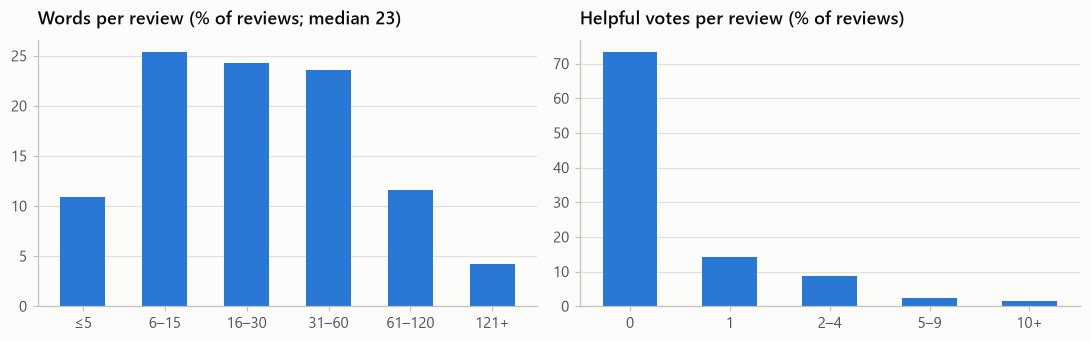

In [5]:
labels = ["0", "1", "2–4", "5–9", "10+"]
votes = pd.cut(df.helpful_vote, bins=[-1, 0, 1, 4, 9, np.inf], labels=labels).value_counts(sort=False)

length_labels = ["≤5", "6–15", "16–30", "31–60", "61–120", "121+"]
lengths = pd.cut(df.word_count, [-1, 5, 15, 30, 60, 120, np.inf], labels=length_labels).value_counts(sort=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, counts_, title in [(axes[0], lengths, f"Words per review (% of reviews; median {df.word_count.median():.0f})"),
                           (axes[1], votes, "Helpful votes per review (% of reviews)")]:
    ax.bar(counts_.index.astype(str), counts_ / len(df) * 100, width=0.55, color=BLUE)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
savefig(fig, "01_length_and_votes")

summary = pd.Series({
    "median words": df.word_count.median(),
    "share with >= 1 helpful vote": df.has_helpful.mean(),
    "mean helpful votes": df.helpful_vote.mean(),
    "max helpful votes": df.helpful_vote.max(),
    "share verified purchase": df.verified_purchase.mean(),
    "share with images": df.has_images.mean(),
    "share with a user-written title": df.has_title.mean(),
    "share of reviews whose product has metadata": df.avg_rating.notna().mean(),
    "share of reviews whose product lists a price": df.price.notna().mean(),
})
summary.round(3).to_frame("value")

## Most reviewers write one review in this category

This limits the reviewer-level analysis (notebook 5). "Systematic" behaviour can only be observed
for reviewers who wrote several reviews.

,reviewers,reviews,share_of_reviewers,share_of_reviews
1,588942,588942,0.932,0.848
2,34843,69686,0.055,0.100
3–4,6724,21616,0.011,0.031
5–9,1153,7030,0.002,0.010
10+,324,6978,0.001,0.010


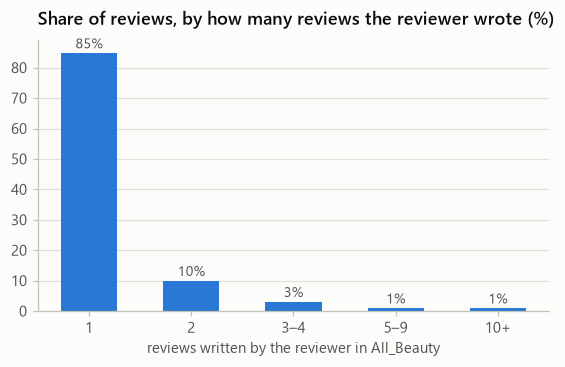

In [6]:
per_user = df.groupby("user_id").size()
activity = pd.cut(per_user, [0, 1, 2, 4, 9, np.inf], labels=["1", "2", "3–4", "5–9", "10+"])
act = pd.DataFrame({"reviewers": activity.value_counts(sort=False),
                    "reviews": per_user.groupby(activity, observed=True).sum()})
act["share_of_reviewers"] = act.reviewers / act.reviewers.sum()
act["share_of_reviews"] = act.reviews / act.reviews.sum()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(act.index.astype(str), 100 * act.share_of_reviews, width=0.55, color=BLUE)
for i, v in enumerate(act.share_of_reviews):
    ax.text(i, 100 * v + 1.5, f"{v:.0%}", ha="center", color=INK_2, fontsize=9)
ax.set_title("Share of reviews, by how many reviews the reviewer wrote (%)")
ax.set_xlabel("reviews written by the reviewer in All_Beauty")
ax.grid(axis="x", visible=False)
savefig(fig, "01_reviewer_activity")
act.round(3)